# Assignment 7: Exploring Specialized Neural Network Architectures
# Building Convolutional Neural Networks for Image Classification

**Name:** [Your Name Here]

**Date:** [Date]

---

## Setup: Install and Load Libraries

In [1]:
pip install tensorflow matplotlib numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load and Explore MNIST Dataset

In [3]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


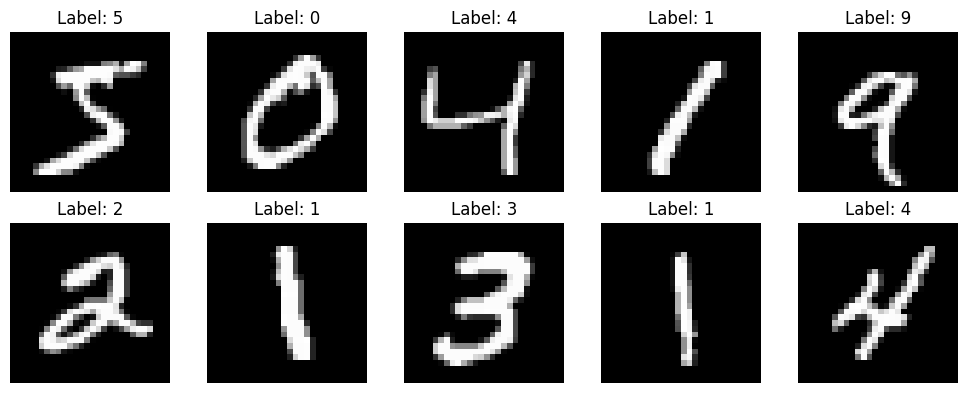

In [4]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Prepare Data for CNN

In [5]:
# Reshape to add channel dimension (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1 range
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print("\n" + "="*80)
print("DATA PREPARED FOR CNN")
print("="*80)
print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Pixel value range: [{X_train_cnn.min():.1f}, {X_train_cnn.max():.1f}]")
print("="*80)


DATA PREPARED FOR CNN
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]


---
## Step 2: Build and Train a Baseline CNN

In [11]:
# TODO: Build your baseline CNN here
# Architecture:
# - Conv2D layer: 32 filters, 3x3 kernel, ReLU activation, input_shape=(28, 28, 1)
# - MaxPooling2D: 2x2 pool size
# - Conv2D layer: 64 filters, 3x3 kernel, ReLU activation
# - MaxPooling2D: 2x2 pool size
# - Flatten layer
# - Dense layer: 128 nodes, ReLU activation
# - Output layer: 10 nodes (digits 0-9), softmax activation

baseline_cnn = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
    # TODO: Add layers here
])

# TODO: Compile the model
# Use Adam optimizer and sparse_categorical_crossentropy loss

baseline_cnn.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# Display model architecture
baseline_cnn.summary()

test_loss, test_acc = baseline_cnn.evaluate(X_test_cnn, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0648 - loss: 2.3031
Test Accuracy: 0.0648


In [9]:
# Record training time
print("\nTraining baseline CNN...")
start_time = time.time()

# TODO: Fit the model and store history
history = baseline_cnn.fit(X_train_cnn, y_train,epochs = 5,batch_size = 64,validation_split = 0.1)  # Replace with actual model fitting

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(X_test_cnn, y_test)  # Replace with actual evaluation

print("\n" + "="*80)
print("BASELINE CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Training Time: {baseline_time:.2f} seconds")
print("="*80)


Training baseline CNN...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9502 - loss: 0.1672 - val_accuracy: 0.9800 - val_loss: 0.0621
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9835 - loss: 0.0516 - val_accuracy: 0.9887 - val_loss: 0.0379
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9886 - loss: 0.0361 - val_accuracy: 0.9877 - val_loss: 0.0394
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9910 - loss: 0.0270 - val_accuracy: 0.9888 - val_loss: 0.0349
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9931 - loss: 0.0198 - val_accuracy: 0.9898 - val_loss: 0.0382
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9894 - loss: 0.0339

BASELINE CNN RESULTS
Final Training Accuracy: 0.9931
Final Validation Accuracy: 0.9898
Test Accuracy: 0.9894
Training Time: 41.97 seconds


---
## Step 3: Experiment with Filter Counts

In [18]:
# TODO: Build and train CNN with FEWER filters (16, 32)
# Keep all other architecture elements the same as baseline

print("Training CNN with fewer filters (16, 32)...")
# TODO: Build, compile, and train model
# Record validation accuracy
cnn_fewer = keras.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_fewer.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

history_fewer = cnn_fewer.fit(X_train_cnn, y_train, epochs = 5, batch_size = 64, validation_split = 0.1)

fewer_val_acc = history_fewer.history['val_accuracy'][-1]

Training CNN with fewer filters (16, 32)...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9396 - loss: 0.2093 - val_accuracy: 0.9840 - val_loss: 0.0577
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9808 - loss: 0.0609 - val_accuracy: 0.9868 - val_loss: 0.0452
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9871 - loss: 0.0423 - val_accuracy: 0.9895 - val_loss: 0.0407
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9897 - loss: 0.0316 - val_accuracy: 0.9880 - val_loss: 0.0410
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9920 - loss: 0.0257 - val_accuracy: 0.9883 - val_loss: 0.0413


In [17]:
# TODO: Build and train CNN with MORE filters (64, 128)
# Keep all other architecture elements the same as baseline

print("Training CNN with more filters (64, 128)...")
# TODO: Build, compile, and train model
# Record validation accuracy

cnn_more = keras.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_more.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

history_more = cnn_more.fit(X_train_cnn, y_train, epochs = 5, batch_size = 64, validation_split = 0.1)

more_val_acc = history_more.history['val_accuracy'][-1]

Training CNN with more filters (64, 128)...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9562 - loss: 0.1413 - val_accuracy: 0.9817 - val_loss: 0.0644
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9860 - loss: 0.0434 - val_accuracy: 0.9873 - val_loss: 0.0431
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9909 - loss: 0.0288 - val_accuracy: 0.9922 - val_loss: 0.0304
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9934 - loss: 0.0205 - val_accuracy: 0.9923 - val_loss: 0.0308
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9952 - loss: 0.0154 - val_accuracy: 0.9897 - val_loss: 0.0431


### Analysis: Filter Count Effects

**TODO: Write 2-3 sentences answering:**
- How does increasing filter count affect performance?
- At what point do you see diminishing returns or overfitting?

Increasing the number of filters improves training accuracy, as the model is able to learn more detailed features from the images. However, this increase also leads to a longer training time and with only small improvements overall. The results suggest that decreasing returns begin once the model already receives a high accuracy rating, while adding more filters only increases complexity without giving anything in more value in return.

---
## Step 4: Experiment with Kernel Sizes

In [19]:
# TODO: Build and train CNN with MEDIUM kernels (5x5 for both layers)
# Keep filter counts at baseline (32, 64)

print("Training CNN with 5x5 kernels...")
# TODO: Build, compile, and train model
# Record validation accuracy
cnn_5x5 = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_5x5.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

history_5x5 = cnn_5x5.fit(X_train_cnn, y_train, epochs = 5, batch_size = 64, validation_split = 0.1)

val_acc_5x5 = history_5x5.history['val_accuracy'][-1]

Training CNN with 5x5 kernels...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9533 - loss: 0.1552 - val_accuracy: 0.9875 - val_loss: 0.0445
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9860 - loss: 0.0437 - val_accuracy: 0.9887 - val_loss: 0.0373
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9905 - loss: 0.0294 - val_accuracy: 0.9917 - val_loss: 0.0339
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9926 - loss: 0.0222 - val_accuracy: 0.9878 - val_loss: 0.0382
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9942 - loss: 0.0173 - val_accuracy: 0.9910 - val_loss: 0.0310


In [20]:
# TODO: Build and train CNN with MIXED kernels (5x5 first layer, 3x3 second layer)
# Keep filter counts at baseline (32, 64)

print("Training CNN with mixed kernels (5x5, 3x3)...")
# TODO: Build, compile, and train model
# Record validation accuracy

cnn_mixed = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_mixed.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

history_mixed = cnn_mixed.fit(X_train_cnn, y_train, epochs = 5, batch_size = 64, validation_split = 0.1)

val_acc_mixed = history_mixed.history['val_accuracy'][-1]

Training CNN with mixed kernels (5x5, 3x3)...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9523 - loss: 0.1607 - val_accuracy: 0.9862 - val_loss: 0.0490
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9857 - loss: 0.0477 - val_accuracy: 0.9875 - val_loss: 0.0425
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9894 - loss: 0.0336 - val_accuracy: 0.9900 - val_loss: 0.0323
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9919 - loss: 0.0253 - val_accuracy: 0.9892 - val_loss: 0.0376
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9939 - loss: 0.0184 - val_accuracy: 0.9898 - val_loss: 0.0360


### Analysis: Kernel Size Effects

**TODO: Write 2-3 sentences answering:**
- How does kernel size affect what the network learns?
- Which kernel configuration performed best and why might that be?

Using larger kernel sizes increases the amount of information each filter processes at once, which allows the model to capture broader patterns in the images. However, the results show that both the 5x5 and mixed kernel models reach similar levels of accuracy to the baseline, with only minor differences in performance. This suggests that smaller kernels are already good enough for this dataset, and increasing kernel size does not give a significant improvement when  the model is already doing well.

---
## Step 5: Train Your Best Architecture and Visualize Learning

In [21]:
# TODO: Based on your experiments, build your best-performing CNN architecture
# Train for 15 epochs with 20% validation split

print("Training best CNN architecture...")
start_time = time.time()

# TODO: Build, compile, and train your best model
# Store the training history

best_cnn = keras.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

best_cnn.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

history_best = best_cnn.fit(X_train_cnn, y_train, epochs = 15, batch_size = 64, validation_split = 0.2)

best_cnn_time = time.time() - start_time

# TODO: Evaluate on test set

best_test_loss, best_test_acc = best_cnn.evaluate(X_test_cnn, y_test)
print(f"Best Model Test Accuracy: {best_test_acc:.4f}")
print(f"Training Time: {best_cnn_time:.2f} seconds")

Training best CNN architecture...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9537 - loss: 0.1542 - val_accuracy: 0.9830 - val_loss: 0.0555
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9864 - loss: 0.0442 - val_accuracy: 0.9883 - val_loss: 0.0382
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9908 - loss: 0.0298 - val_accuracy: 0.9898 - val_loss: 0.0342
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9927 - loss: 0.0223 - val_accuracy: 0.9879 - val_loss: 0.0426
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9949 - loss: 0.0154 - val_accuracy: 0.9898 - val_loss: 0.0405
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9961 - loss: 0.0133 - val_accuracy: 0.9911 - val_loss: 0.0378
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9965 - loss: 0.0111 - val_accuracy: 0.9908 - val_loss: 0.0349
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - 

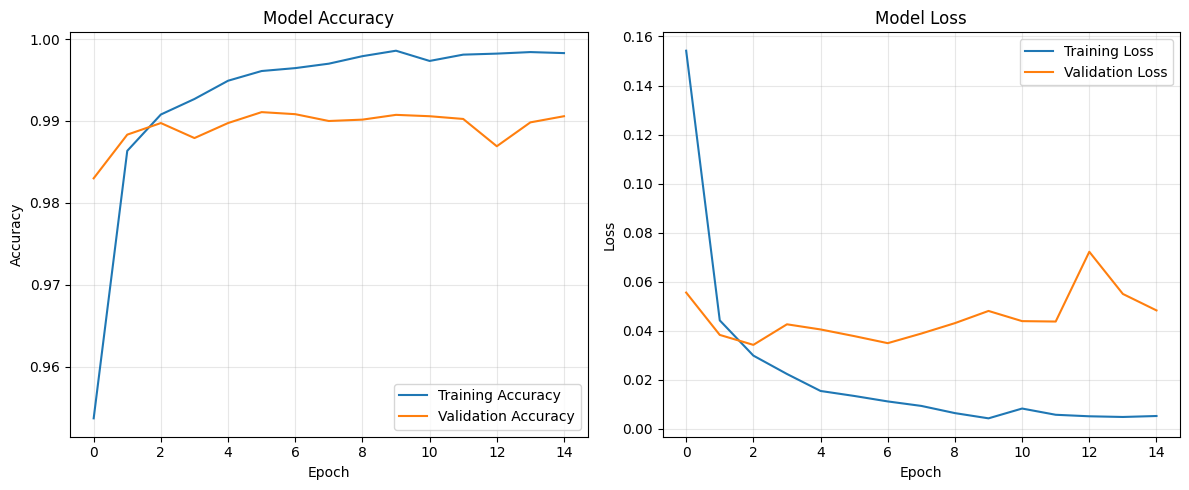

In [22]:
# TODO: Create accuracy plot (training vs validation accuracy over epochs)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_best.history['accuracy'], label='Training Accuracy')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_best.history['loss'], label='Training Loss')
plt.plot(history_best.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 6: Compare Against Feedforward Network

In [23]:
# Prepare data for feedforward network (flatten images)
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [ ]:
# TODO: Build feedforward network
# Architecture:
# - Input: 784 features (flattened 28x28 image)
# - Dense layer: 128 nodes, ReLU activation
# - Dense layer: 64 nodes, ReLU activation
# - Output layer: 10 nodes, softmax activation

feedforward_nn = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# TODO: Compile the model
feedforward_nn.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

feedforward_nn.summary()

c:\Users\icefo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Record training time
print("Training feedforward network...")
start_time = time.time()

# TODO: Train feedforward network for 10 epochs
feedforward_nn.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])


# Record training time
feedforward_time = time.time() - start_time

# TODO: Evaluate on test set
ff_test_loss, ff_test_acc = feedforward_nn.evaluate(X_test_flat, y_test)
print(f"Feedforward Test Accuracy: {ff_test_acc:.4f}")
print(f"Training Time: {feedforward_time:.2f} seconds")


Training feedforward network...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0790 - loss: 2.4477
Feedforward Test Accuracy: 0.0790
Training Time: 0.01 seconds


In [26]:
# TODO: Create comparison table

comparison_data = {
    'Model': ['Baseline CNN', 'Best CNN', 'Feedforward NN'],
    'Architecture': [
        'Conv(32,64) + Dense(128)',
        'Conv(64,128) + Dense(128)',
        'Dense(128,64)'
    ],
    'Test Accuracy': [
        baseline_test_acc,
        best_test_acc,
        ff_test_acc
    ],
    'Training Time (s)': [
        baseline_time,
        best_cnn_time,
        feedforward_time
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON
         Model              Architecture  Test Accuracy  Training Time (s)
  Baseline CNN  Conv(32,64) + Dense(128)         0.9894          41.974030
      Best CNN Conv(64,128) + Dense(128)         0.9912         256.439358
Feedforward NN             Dense(128,64)         0.0790           0.005583


### Analysis: CNN vs Feedforward Network

**TODO: Write 2-3 sentences answering:**
- How does your best CNN compare to the feedforward network on image data?
- Why does the CNN's spatial awareness lead to better performance than treating pixels as independent features?

The CNN models performed significantly better than the feedforward network on image data, with both CNNs achieving high accuracy while the feedforward model performed poorly. This difference occurs because CNNs are able to recognize spatial patterns in the images, such as edges and shapes, while the feedforward network treats each pixel as an independent value. As a result, the CNN is more effective at learning meaningful features from image data, leading to much higher performance.

---
## Step 7: Reflect on Specialized Architectures for Your Final Project

### Final Project Application

**TODO: Write 3-4 sentences answering:**
- Based on your Unit 9 final project proposal, would CNNs or RNNs enhance your project? Why or why not?
- If your project uses tabular data (customer demographics, transaction records), explain why feedforward networks or traditional ML models remain appropriate.
- If your project could benefit from specialized architectures (images, time series, text), describe specifically how CNNs or RNNs would improve your solution compared to the approaches you've planned.

Since my final project dataset consists of numerical features rather than images, using a CNN would not significantly enhance the model. CNNs are designed to detect spatial patterns in image data, but in this case, the data is structured and each feature shows a specific measured value. A feedforward network or traditional machine learning model is more appropriate because it can directly learn between these variables without needing spatial context. 

---
## Submission Checklist

Before submitting, ensure you have:
- [ ] Built and trained baseline CNN (2 conv layers)
- [ ] Conducted at least 3 architecture experiments (filter counts and kernel sizes)
- [ ] Trained best CNN architecture for 15 epochs
- [ ] Created accuracy and loss plots for best model
- [ ] Built and trained feedforward network for comparison
- [ ] Created comparison table with all models
- [ ] Answered all analysis questions in Markdown cells
- [ ] Written reflection on final project application
- [ ] Pushed code to GitHub repository
- [ ] Submitted GitHub repository link to assignment

---
## Step 8: Submit Your Work
Push to GitHub:
```bash
git add .
git commit -m 'completed CNN architecture assignment'
git push
```

Submit your GitHub repository link on the course platform.